In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

idp_path = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/merged_IDP_result_filtered.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2/partial_fit_5std")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/idp_phenowas_brain")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_idp_samples = 10000  # Filter to IDP fields with > 10000 samples
min_regression_samples = 10000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain PhenoWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

idp_data = pd.read_csv(idp_path)
idp_data["eid"] = idp_data["eid"].astype(int)
meta_cols = ["eid"]  # IDP data only has eid as metadata column
idp_columns = [c for c in idp_data.columns if c not in meta_cols]

# Filter IDP fields to only those with > min_samples non-NaN values
print(f"Filtering IDP fields to those with > {min_idp_samples} samples...")
idp_sample_counts = idp_data[idp_columns].notna().sum()
valid_idp_fields = idp_sample_counts[idp_sample_counts > min_idp_samples].index.tolist()
print(f"Found {len(valid_idp_fields)} IDP fields with > {min_idp_samples} samples (out of {len(idp_columns)} total)")
idp_columns = valid_idp_fields

trait_files = sorted(trait_dir.glob("Feature_*.csv"))
print(f"Found {len(idp_columns)} IDP fields (filtered to > {min_idp_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(idp_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")
    
    # Handle NA values in trait: drop rows with NA trait values
    trait_df = trait_df.dropna(subset=[trait_name])
    if trait_df.empty:
        print(f"Skipping {trait_path.name} (all trait values are NA).")
        continue

    merged = (
        idp_data.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    # Handle NA values in continuous covariates: fill with median
    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    for col in numeric_design.columns:
        if numeric_design[col].isna().any():
            median_val = numeric_design[col].median()
            if pd.notna(median_val):
                numeric_design[col] = numeric_design[col].fillna(median_val)
            else:
                # If all values are NA, drop the column
                numeric_design = numeric_design.drop(columns=[col])
                if col in local_cont:
                    local_cont.remove(col)
    
    # Handle categorical covariates: fill NA with "missing" category
    cat_frames = []
    for col in local_cat:
        cat_series = merged[col].fillna("missing")
        cat_frames.append(pd.get_dummies(cat_series, prefix=col, drop_first=True))
    
    if cat_frames:
        design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    else:
        design_matrix = numeric_design.copy()
    
    # Drop rows where trait_name is still NA (shouldn't happen, but safety check)
    design_matrix = design_matrix.dropna(subset=[trait_name])
    
    # For other columns, drop rows with any remaining NA (conservative approach)
    design_matrix = design_matrix.dropna()
    
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for idp_field in idp_columns:
        y = merged.loc[design_index, idp_field].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "idp_field": idp_field,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_phenowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} IDP field tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_phenowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering IDP fields to those with > 10000 samples...
Found 179 IDP fields with > 10000 samples (out of 179 total)
Found 179 IDP fields (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 22912
Finished Feature_0.csv: 179 IDP field tests saved.
Finished Feature_1.csv: 179 IDP field tests saved.
Finished Feature_10.csv: 179 IDP field tests saved.
Finished Feature_100.csv: 179 IDP field tests saved.
Finished Feature_101.csv: 179 IDP field tests saved.
Finished Feature_102.csv: 179 IDP field tests saved.
Finished Feature_103.csv: 179 IDP field tests saved.
Finished Feature_104.csv: 179 IDP field tests saved.
Finished Feature_105.csv: 179 IDP field tests saved.
Finished Feature_106.csv: 179 IDP field tests saved.
Finished Feature_107.csv: 179 IDP field tests saved.
Finished Feature_108.csv: 179 IDP field tests saved.
Finished Feature_109.csv: 179 IDP field tests saved.
Finished Feature_11.csv: 179 IDP f

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

idp_path = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/merged_IDP_result.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2_T2_5std")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/idp_phenowas_brain_T2")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_idp_samples = 10000  # Filter to IDP fields with > 10000 samples
min_regression_samples = 1000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain PhenoWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

idp_data = pd.read_csv(idp_path)
idp_data["eid"] = idp_data["eid"].astype(int)
meta_cols = ["eid"]  # IDP data only has eid as metadata column
idp_columns = [c for c in idp_data.columns if c not in meta_cols]

# Filter IDP fields to only those with > min_samples non-NaN values
print(f"Filtering IDP fields to those with > {min_idp_samples} samples...")
idp_sample_counts = idp_data[idp_columns].notna().sum()
valid_idp_fields = idp_sample_counts[idp_sample_counts > min_idp_samples].index.tolist()
print(f"Found {len(valid_idp_fields)} IDP fields with > {min_idp_samples} samples (out of {len(idp_columns)} total)")
idp_columns = valid_idp_fields

trait_files = sorted(trait_dir.glob("Feature_*.csv"))
print(f"Found {len(idp_columns)} IDP fields (filtered to > {min_idp_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(idp_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")
    
    # Handle NA values in trait: drop rows with NA trait values
    trait_df = trait_df.dropna(subset=[trait_name])
    if trait_df.empty:
        print(f"Skipping {trait_path.name} (all trait values are NA).")
        continue

    merged = (
        idp_data.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    # Handle NA values in continuous covariates: fill with median
    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    for col in numeric_design.columns:
        if numeric_design[col].isna().any():
            median_val = numeric_design[col].median()
            if pd.notna(median_val):
                numeric_design[col] = numeric_design[col].fillna(median_val)
            else:
                # If all values are NA, drop the column
                numeric_design = numeric_design.drop(columns=[col])
                if col in local_cont:
                    local_cont.remove(col)
    
    # Handle categorical covariates: fill NA with "missing" category
    cat_frames = []
    for col in local_cat:
        cat_series = merged[col].fillna("missing")
        cat_frames.append(pd.get_dummies(cat_series, prefix=col, drop_first=True))
    
    if cat_frames:
        design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    else:
        design_matrix = numeric_design.copy()
    
    # Drop rows where trait_name is still NA (shouldn't happen, but safety check)
    design_matrix = design_matrix.dropna(subset=[trait_name])
    
    # For other columns, drop rows with any remaining NA (conservative approach)
    design_matrix = design_matrix.dropna()
    
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for idp_field in idp_columns:
        y = merged.loc[design_index, idp_field].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "idp_field": idp_field,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_phenowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} IDP field tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_phenowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering IDP fields to those with > 10000 samples...
Found 179 IDP fields with > 10000 samples (out of 358 total)
Found 179 IDP fields (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 22912
Finished Feature_0.csv: 179 IDP field tests saved.
Finished Feature_1.csv: 179 IDP field tests saved.
Finished Feature_10.csv: 179 IDP field tests saved.
Finished Feature_100.csv: 179 IDP field tests saved.
Finished Feature_101.csv: 179 IDP field tests saved.
Finished Feature_102.csv: 179 IDP field tests saved.
Finished Feature_103.csv: 179 IDP field tests saved.
Finished Feature_104.csv: 179 IDP field tests saved.
Finished Feature_105.csv: 179 IDP field tests saved.
Finished Feature_106.csv: 179 IDP field tests saved.
Finished Feature_107.csv: 179 IDP field tests saved.
Finished Feature_108.csv: 179 IDP field tests saved.
Finished Feature_109.csv: 179 IDP field tests saved.
Finished Feature_11.csv: 179 IDP f

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

idp_path = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/merged_IDP_result_filtered.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/vit_t1_fixed")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/idp_phenowas_brain_vit")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_idp_samples = 10000  # Filter to IDP fields with > 10000 samples
min_regression_samples = 10000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain PhenoWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

idp_data = pd.read_csv(idp_path)
idp_data["eid"] = idp_data["eid"].astype(int)
meta_cols = ["eid"]  # IDP data only has eid as metadata column
idp_columns = [c for c in idp_data.columns if c not in meta_cols]

# Filter IDP fields to only those with > min_samples non-NaN values
print(f"Filtering IDP fields to those with > {min_idp_samples} samples...")
idp_sample_counts = idp_data[idp_columns].notna().sum()
valid_idp_fields = idp_sample_counts[idp_sample_counts > min_idp_samples].index.tolist()
print(f"Found {len(valid_idp_fields)} IDP fields with > {min_idp_samples} samples (out of {len(idp_columns)} total)")
idp_columns = valid_idp_fields

trait_files = sorted(trait_dir.glob("Feature_*"))
print(f"Found {len(idp_columns)} IDP fields (filtered to > {min_idp_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(idp_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")
    
    # Handle NA values in trait: drop rows with NA trait values
    trait_df = trait_df.dropna(subset=[trait_name])
    if trait_df.empty:
        print(f"Skipping {trait_path.name} (all trait values are NA).")
        continue

    merged = (
        idp_data.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    # Handle NA values in continuous covariates: fill with median
    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    for col in numeric_design.columns:
        if numeric_design[col].isna().any():
            median_val = numeric_design[col].median()
            if pd.notna(median_val):
                numeric_design[col] = numeric_design[col].fillna(median_val)
            else:
                # If all values are NA, drop the column
                numeric_design = numeric_design.drop(columns=[col])
                if col in local_cont:
                    local_cont.remove(col)
    
    # Handle categorical covariates: fill NA with "missing" category
    cat_frames = []
    for col in local_cat:
        cat_series = merged[col].fillna("missing")
        cat_frames.append(pd.get_dummies(cat_series, prefix=col, drop_first=True))
    
    if cat_frames:
        design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    else:
        design_matrix = numeric_design.copy()
    
    # Drop rows where trait_name is still NA (shouldn't happen, but safety check)
    design_matrix = design_matrix.dropna(subset=[trait_name])
    
    # For other columns, drop rows with any remaining NA (conservative approach)
    design_matrix = design_matrix.dropna()
    
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for idp_field in idp_columns:
        y = merged.loc[design_index, idp_field].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "idp_field": idp_field,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_phenowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} IDP field tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_phenowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering IDP fields to those with > 10000 samples...
Found 179 IDP fields with > 10000 samples (out of 179 total)
Found 179 IDP fields (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 22912
Finished Feature_0: 179 IDP field tests saved.
Finished Feature_1: 179 IDP field tests saved.
Finished Feature_10: 179 IDP field tests saved.
Finished Feature_100: 179 IDP field tests saved.
Finished Feature_101: 179 IDP field tests saved.
Finished Feature_102: 179 IDP field tests saved.
Finished Feature_103: 179 IDP field tests saved.
Finished Feature_104: 179 IDP field tests saved.
Finished Feature_105: 179 IDP field tests saved.
Finished Feature_106: 179 IDP field tests saved.
Finished Feature_107: 179 IDP field tests saved.
Finished Feature_108: 179 IDP field tests saved.
Finished Feature_109: 179 IDP field tests saved.
Finished Feature_11: 179 IDP field tests saved.
Finished Feature_110: 179 IDP field te

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

idp_path = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/merged_IDP_result_filtered.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/vit_t2_fixed")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/idp_phenowas_brain_T2_vit")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_idp_samples = 10000  # Filter to IDP fields with > 10000 samples
min_regression_samples = 10000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain PhenoWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

idp_data = pd.read_csv(idp_path)
idp_data["eid"] = idp_data["eid"].astype(int)
meta_cols = ["eid"]  # IDP data only has eid as metadata column
idp_columns = [c for c in idp_data.columns if c not in meta_cols]

# Filter IDP fields to only those with > min_samples non-NaN values
print(f"Filtering IDP fields to those with > {min_idp_samples} samples...")
idp_sample_counts = idp_data[idp_columns].notna().sum()
valid_idp_fields = idp_sample_counts[idp_sample_counts > min_idp_samples].index.tolist()
print(f"Found {len(valid_idp_fields)} IDP fields with > {min_idp_samples} samples (out of {len(idp_columns)} total)")
idp_columns = valid_idp_fields

trait_files = sorted(trait_dir.glob("Feature_*"))
print(f"Found {len(idp_columns)} IDP fields (filtered to > {min_idp_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(idp_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")
    
    # Handle NA values in trait: drop rows with NA trait values
    trait_df = trait_df.dropna(subset=[trait_name])
    if trait_df.empty:
        print(f"Skipping {trait_path.name} (all trait values are NA).")
        continue

    merged = (
        idp_data.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    # Handle NA values in continuous covariates: fill with median
    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    for col in numeric_design.columns:
        if numeric_design[col].isna().any():
            median_val = numeric_design[col].median()
            if pd.notna(median_val):
                numeric_design[col] = numeric_design[col].fillna(median_val)
            else:
                # If all values are NA, drop the column
                numeric_design = numeric_design.drop(columns=[col])
                if col in local_cont:
                    local_cont.remove(col)
    
    # Handle categorical covariates: fill NA with "missing" category
    cat_frames = []
    for col in local_cat:
        cat_series = merged[col].fillna("missing")
        cat_frames.append(pd.get_dummies(cat_series, prefix=col, drop_first=True))
    
    if cat_frames:
        design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    else:
        design_matrix = numeric_design.copy()
    
    # Drop rows where trait_name is still NA (shouldn't happen, but safety check)
    design_matrix = design_matrix.dropna(subset=[trait_name])
    
    # For other columns, drop rows with any remaining NA (conservative approach)
    design_matrix = design_matrix.dropna()
    
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for idp_field in idp_columns:
        y = merged.loc[design_index, idp_field].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "idp_field": idp_field,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_phenowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} IDP field tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_phenowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering IDP fields to those with > 10000 samples...
Found 179 IDP fields with > 10000 samples (out of 179 total)
Found 179 IDP fields (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 22912
Finished Feature_0: 179 IDP field tests saved.
Finished Feature_1: 179 IDP field tests saved.
Finished Feature_10: 179 IDP field tests saved.
Finished Feature_100: 179 IDP field tests saved.
Finished Feature_101: 179 IDP field tests saved.
Finished Feature_102: 179 IDP field tests saved.
Finished Feature_103: 179 IDP field tests saved.
Finished Feature_104: 179 IDP field tests saved.
Finished Feature_105: 179 IDP field tests saved.
Finished Feature_106: 179 IDP field tests saved.
Finished Feature_107: 179 IDP field tests saved.
Finished Feature_108: 179 IDP field tests saved.
Finished Feature_109: 179 IDP field tests saved.
Finished Feature_11: 179 IDP field tests saved.
Finished Feature_110: 179 IDP field te

=== Univariate Analysis: All IDPs + Covariates vs All Traits ===

Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering IDP fields to those with > 10000 samples...
Found 179 IDP fields with > 10000 samples (out of 179 total)
Found 128 trait files to analyze
Found 179 IDP fields and 48 continuous covariates to analyze



Processing traits: 100%|██████████| 128/128 [01:38<00:00,  1.30it/s]



=== Summary ===
Total predictor-trait pairs analyzed: 29568
Number of unique traits: 128
Number of unique predictors: 231
  - IDPs: 179
  - Continuous covariates: 48
  - Categorical covariates: 4
Total number of tests: 29568

Results saved to: /data484_4/txia2/mocov2/IDP_PhenoWAS/idp_phenowas_brain_partialfit_5std_covar/idp_covar_trait_univariate_analysis.csv

=== Association Statistics ===
Mean |beta|: 0.280291
Median |beta|: 0.003687
Max |beta|: 752.898302
Min |beta|: 0.000000

Significant associations (p < 0.05, uncorrected): 18695 (63.23%)
Significant associations (p < 0.05, Bonferroni corrected): 11014 (37.25%)

=== Top 20 Most Significant Associations (by p-value) ===
trait            predictor        predictor_type        beta  p_value  p_bonferroni  n_samples
pca_0            25024-2.0                   IDP   -1.058614      0.0           0.0      22947
pca_0            25890-2.0                   IDP   -0.967504      0.0           0.0      22947
pca_0            25891-2.0     

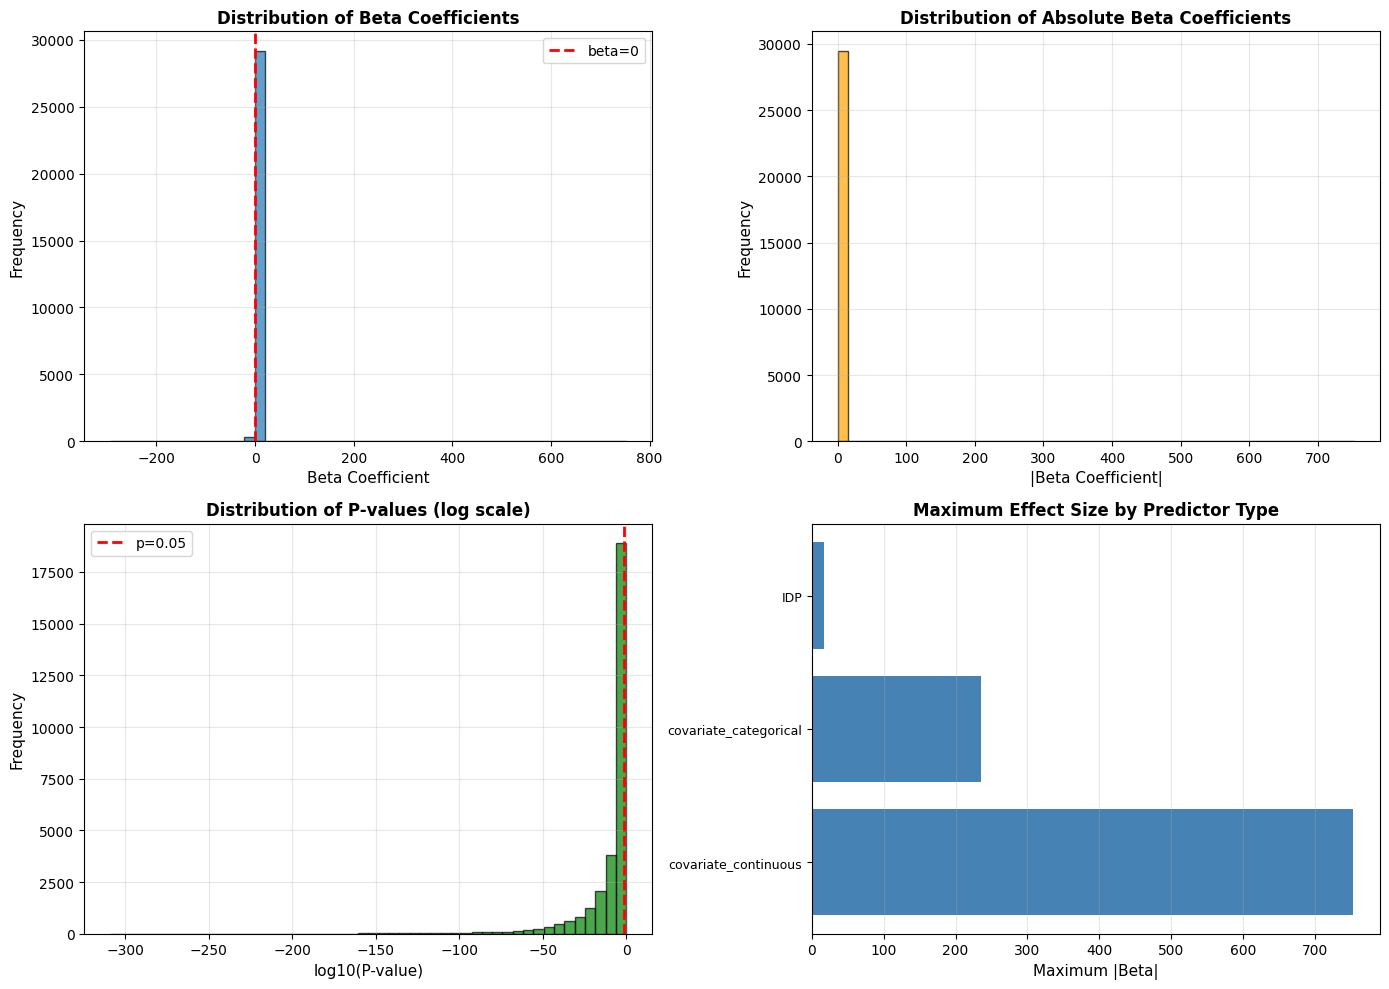


=== Summary by Predictor Type ===
                       mean_beta   std_beta    min_beta    max_beta  mean_abs_beta  max_abs_beta  n_sig
predictor_type                                                                                         
covariate_continuous    0.074643  11.718141 -294.225506  752.898302       0.751733    752.898302   1400
covariate_categorical   0.579183  15.343644 -235.218858  120.075452       5.749796    235.218858    286
IDP                    -0.002179   0.265311  -17.453356   15.827885       0.031647     17.453356  17009

Predictor type summary saved to: /data484_4/txia2/mocov2/IDP_PhenoWAS/idp_phenowas_brain_partialfit_5std_covar/predictor_type_summary_stats.csv

=== Summary by Trait ===
        mean_beta   std_beta    min_beta    max_beta  mean_abs_beta  max_abs_beta  n_sig
trait                                                                                   
pca_1    2.097012  52.066871 -235.218858  752.898302       5.202283    752.898302    182
pca_0  

In [1]:
# Univariate analysis: Associations between all IDPs + covariates and all traits
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

idp_path = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/merged_IDP_result_filtered.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2/partial_fit_5std")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/IDP_PhenoWAS/idp_phenowas_brain_partialfit_5std_covar")
output_dir.mkdir(parents=True, exist_ok=True)

from scipy import stats
import matplotlib.pyplot as plt
try:
    from tqdm import tqdm
except ImportError:
    # Fallback if tqdm is not available
    def tqdm(iterable, desc=""):
        print(f"{desc}...")
        return iterable

print("=== Univariate Analysis: All IDPs + Covariates vs All Traits ===\n")

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain PhenoWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

# Load UKB covariates
ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

# Load IDP data
idp_data = pd.read_csv(idp_path)
idp_data["eid"] = idp_data["eid"].astype(int)
meta_cols = ["eid"]
idp_columns = [c for c in idp_data.columns if c not in meta_cols]

# Filter IDP fields to only those with > min_samples non-NaN values
min_idp_samples = 10000
print(f"Filtering IDP fields to those with > {min_idp_samples} samples...")
idp_sample_counts = idp_data[idp_columns].notna().sum()
valid_idp_fields = idp_sample_counts[idp_sample_counts > min_idp_samples].index.tolist()
print(f"Found {len(valid_idp_fields)} IDP fields with > {min_idp_samples} samples (out of {len(idp_columns)} total)")
idp_columns = valid_idp_fields

# Get all trait files
trait_files = sorted(trait_dir.glob("Feature_*.csv"))
print(f"Found {len(trait_files)} trait files to analyze")
print(f"Found {len(idp_columns)} IDP fields and {len(continuous_covars)} continuous covariates to analyze\n")

# Prepare results storage
all_results = []

# Process each trait file
for trait_path in tqdm(trait_files, desc="Processing traits"):
    try:
        trait_df = pd.read_csv(trait_path, sep=r'\s+')
        trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
        if not trait_cols:
            continue
        trait_name = trait_cols[0]
        trait_df = trait_df.rename(columns={"IID": "eid"})
        trait_df["eid"] = trait_df["eid"].astype(int)
        trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")
        
        # Handle NA values in trait: drop rows with NA trait values
        trait_df = trait_df.dropna(subset=[trait_name])
        if trait_df.empty:
            continue

        # Merge trait with IDPs and covariates
        merged = (
            trait_df.merge(idp_data, on="eid", how="inner")
            .merge(covars, on="eid", how="inner")
        )
        if merged.empty:
            continue

        # Convert trait to numeric
        y = pd.to_numeric(merged[trait_name], errors='coerce')
        valid_trait_mask = y.notna()
        
        if valid_trait_mask.sum() < 10:
            continue
        
        y_clean = y[valid_trait_mask].values.astype(float)
        merged_clean = merged[valid_trait_mask].copy()
        
        # Test each IDP as predictor of trait (univariate regression)
        for predictor_name in idp_columns:
            if predictor_name not in merged_clean.columns:
                continue
            
            x = pd.to_numeric(merged_clean[predictor_name], errors='coerce')
            valid_mask = x.notna()
            
            if valid_mask.sum() < 10:
                continue
            
            x_clean = x[valid_mask].values.astype(float)
            y_subset = y_clean[valid_mask.values]
            
            if len(x_clean) < 10 or np.any(~np.isfinite(x_clean)) or np.any(~np.isfinite(y_subset)):
                continue
            
            try:
                # Univariate regression: trait ~ predictor
                X = sm.add_constant(x_clean)
                model = sm.OLS(y_subset, X).fit()
                
                beta = model.params[1] if len(model.params) > 1 else np.nan
                p_value = model.pvalues[1] if len(model.pvalues) > 1 else np.nan
                
                if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
                    continue
                
                all_results.append({
                    "trait": trait_name,
                    "trait_file": trait_path.name,
                    "predictor": predictor_name,
                    "predictor_type": "IDP",
                    "n_samples": int(len(x_clean)),
                    "beta": beta,
                    "p_value": p_value,
                })
            except:
                continue
        
        # Test each continuous covariate as predictor of trait (univariate regression)
        for covar in continuous_covars:
            if covar not in merged_clean.columns:
                continue
            
            x = pd.to_numeric(merged_clean[covar], errors='coerce')
            valid_mask = x.notna()
            
            if valid_mask.sum() < 10:
                continue
            
            x_clean = x[valid_mask].values.astype(float)
            y_subset = y_clean[valid_mask.values]
            
            if len(x_clean) < 10 or np.any(~np.isfinite(x_clean)) or np.any(~np.isfinite(y_subset)):
                continue
            
            try:
                # Univariate regression: trait ~ covariate
                X = sm.add_constant(x_clean)
                model = sm.OLS(y_subset, X).fit()
                
                beta = model.params[1] if len(model.params) > 1 else np.nan
                p_value = model.pvalues[1] if len(model.pvalues) > 1 else np.nan
                
                if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
                    continue
                
                all_results.append({
                    "trait": trait_name,
                    "trait_file": trait_path.name,
                    "predictor": covar,
                    "predictor_type": "covariate_continuous",
                    "n_samples": int(len(x_clean)),
                    "beta": beta,
                    "p_value": p_value,
                })
            except:
                continue
        
        # Test each categorical covariate as predictor of trait (univariate regression with dummy encoding)
        for covar in categorical_covars:
            if covar not in merged_clean.columns:
                continue
            
            cat_series = merged_clean[covar].fillna("missing")
            cat_dummies = pd.get_dummies(cat_series, prefix=covar, drop_first=True)
            
            if cat_dummies.empty or cat_dummies.shape[1] == 0:
                continue
            
            # For each dummy variable, test univariate association
            for dummy_col in cat_dummies.columns:
                x = cat_dummies[dummy_col].values.astype(float)
                valid_mask = np.ones(len(x), dtype=bool)  # Dummy variables are always valid
                
                if valid_mask.sum() < 10:
                    continue
                
                x_clean = x[valid_mask]
                y_subset = y_clean[valid_mask]
                
                if len(x_clean) < 10 or np.any(~np.isfinite(x_clean)) or np.any(~np.isfinite(y_subset)):
                    continue
                
                try:
                    # Univariate regression: trait ~ dummy_variable
                    X = sm.add_constant(x_clean)
                    model = sm.OLS(y_subset, X).fit()
                    
                    beta = model.params[1] if len(model.params) > 1 else np.nan
                    p_value = model.pvalues[1] if len(model.pvalues) > 1 else np.nan
                    
                    if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
                        continue
                    
                    all_results.append({
                        "trait": trait_name,
                        "trait_file": trait_path.name,
                        "predictor": dummy_col,
                        "predictor_type": "covariate_categorical",
                        "n_samples": int(len(x_clean)),
                        "beta": beta,
                        "p_value": p_value,
                    })
                except:
                    continue
                    
    except Exception as e:
        print(f"Error processing {trait_path.name}: {e}")
        continue

# Create results dataframe
if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Calculate Bonferroni correction
    n_tests = len(results_df)
    results_df["p_bonferroni"] = np.minimum(results_df["p_value"] * n_tests, 1.0)
    
    # Sort by absolute beta (effect size)
    results_df["abs_beta"] = results_df["beta"].abs()
    results_df = results_df.sort_values("p_value")
    
    print(f"\n=== Summary ===")
    print(f"Total predictor-trait pairs analyzed: {len(results_df)}")
    print(f"Number of unique traits: {results_df['trait'].nunique()}")
    print(f"Number of unique predictors: {results_df['predictor'].nunique()}")
    print(f"  - IDPs: {len(results_df[results_df['predictor_type'] == 'IDP']['predictor'].unique())}")
    print(f"  - Continuous covariates: {len(results_df[results_df['predictor_type'] == 'covariate_continuous']['predictor'].unique())}")
    print(f"  - Categorical covariates: {len(results_df[results_df['predictor_type'] == 'covariate_categorical']['predictor'].unique())}")
    print(f"Total number of tests: {n_tests}")
    
    # Save results
    output_file = output_dir / "idp_covar_trait_univariate_analysis.csv"
    results_df.to_csv(output_file, index=False)
    print(f"\nResults saved to: {output_file}")
    
    # Summary statistics
    print(f"\n=== Association Statistics ===")
    print(f"Mean |beta|: {results_df['abs_beta'].mean():.6f}")
    print(f"Median |beta|: {results_df['abs_beta'].median():.6f}")
    print(f"Max |beta|: {results_df['abs_beta'].max():.6f}")
    print(f"Min |beta|: {results_df['abs_beta'].min():.6f}")
    
    # Count significant associations
    sig_uncorrected = (results_df["p_value"] < 0.05).sum()
    sig_bonf = (results_df["p_bonferroni"] < 0.05).sum()
    print(f"\nSignificant associations (p < 0.05, uncorrected): {sig_uncorrected} ({100*sig_uncorrected/len(results_df):.2f}%)")
    print(f"Significant associations (p < 0.05, Bonferroni corrected): {sig_bonf} ({100*sig_bonf/len(results_df):.2f}%)")
    
    # Top associations
    print(f"\n=== Top 20 Most Significant Associations (by p-value) ===")
    top_assoc = results_df.head(20)[["trait", "predictor", "predictor_type", "beta", "p_value", "p_bonferroni", "n_samples"]]
    print(top_assoc.to_string(index=False))
    
    # Create visualizations
    print(f"\n=== Creating Visualizations ===")
    
    # 1. Distribution of beta coefficients
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histogram of beta coefficients
    axes[0, 0].hist(results_df["beta"], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='beta=0')
    axes[0, 0].set_xlabel("Beta Coefficient", fontsize=11)
    axes[0, 0].set_ylabel("Frequency", fontsize=11)
    axes[0, 0].set_title("Distribution of Beta Coefficients", fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Histogram of absolute beta coefficients
    axes[0, 1].hist(results_df["abs_beta"], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_xlabel("|Beta Coefficient|", fontsize=11)
    axes[0, 1].set_ylabel("Frequency", fontsize=11)
    axes[0, 1].set_title("Distribution of Absolute Beta Coefficients", fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # P-value distribution (log scale)
    valid_p = results_df["p_value"][results_df["p_value"] > 0]
    if len(valid_p) > 0:
        axes[1, 0].hist(np.log10(valid_p), bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[1, 0].axvline(np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
        axes[1, 0].set_xlabel("log10(P-value)", fontsize=11)
        axes[1, 0].set_ylabel("Frequency", fontsize=11)
        axes[1, 0].set_title("Distribution of P-values (log scale)", fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Top predictors by type
    top_by_type = results_df.groupby("predictor_type")["abs_beta"].max().sort_values(ascending=False)
    axes[1, 1].barh(range(len(top_by_type)), top_by_type.values, color='steelblue')
    axes[1, 1].set_yticks(range(len(top_by_type)))
    axes[1, 1].set_yticklabels(top_by_type.index, fontsize=9)
    axes[1, 1].set_xlabel("Maximum |Beta|", fontsize=11)
    axes[1, 1].set_title("Maximum Effect Size by Predictor Type", fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(output_dir / "idp_covar_trait_univariate_summary.png", dpi=300, bbox_inches='tight')
    print(f"Summary plot saved to: {output_dir / 'idp_covar_trait_univariate_summary.png'}")
    plt.show()
    
    # 2. Summary by predictor type
    print("\n=== Summary by Predictor Type ===")
    type_summary = results_df.groupby("predictor_type").agg({
        "beta": ["mean", "std", "min", "max"],
        "abs_beta": ["mean", "max"],
        "p_value": lambda x: (x < 0.05).sum(),
    }).round(6)
    type_summary.columns = ["mean_beta", "std_beta", "min_beta", "max_beta", "mean_abs_beta", "max_abs_beta", "n_sig"]
    type_summary = type_summary.sort_values("max_abs_beta", ascending=False)
    print(type_summary.to_string())
    
    # Save predictor type summary
    type_summary.to_csv(output_dir / "predictor_type_summary_stats.csv")
    print(f"\nPredictor type summary saved to: {output_dir / 'predictor_type_summary_stats.csv'}")
    
    # 3. Summary by trait
    print("\n=== Summary by Trait ===")
    trait_summary = results_df.groupby("trait").agg({
        "beta": ["mean", "std", "min", "max"],
        "abs_beta": ["mean", "max"],
        "p_value": lambda x: (x < 0.05).sum(),
    }).round(6)
    trait_summary.columns = ["mean_beta", "std_beta", "min_beta", "max_beta", "mean_abs_beta", "max_abs_beta", "n_sig"]
    trait_summary = trait_summary.sort_values("max_abs_beta", ascending=False)
    print(trait_summary.head(20).to_string())
    
    # Save trait summary
    trait_summary.to_csv(output_dir / "trait_summary_stats.csv")
    print(f"\nTrait summary saved to: {output_dir / 'trait_summary_stats.csv'}")
    
    # 4. Summary by predictor (top predictors)
    print("\n=== Summary by Predictor (Top 20) ===")
    predictor_summary = results_df.groupby("predictor").agg({
        "beta": ["mean", "std", "min", "max"],
        "abs_beta": ["mean", "max"],
        "p_value": lambda x: (x < 0.05).sum(),
    }).round(6)
    predictor_summary.columns = ["mean_beta", "std_beta", "min_beta", "max_beta", "mean_abs_beta", "max_abs_beta", "n_sig"]
    predictor_summary = predictor_summary.sort_values("max_abs_beta", ascending=False)
    print(predictor_summary.head(20).to_string())
    
    # Save predictor summary
    predictor_summary.to_csv(output_dir / "predictor_summary_stats.csv")
    print(f"\nPredictor summary saved to: {output_dir / 'predictor_summary_stats.csv'}")
    
    print("\n=== Analysis Complete ===")
else:
    print("No results generated. Check data availability.")
